## Technology Innovetion Project
* Name: Krishma Krishma
* Student ID: 104659684
* Email: 104659684@student.swin.edu.au

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## Data Loading and Data Cleaning

In [20]:
data = pd.read_csv('fraudTest.csv')
print("data shape:", data.shape)
print(data.info())

data shape: (555719, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  float64
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long       

In [21]:
data.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,6/21/2020 12:14,2.291164e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,3/19/1968,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,6/21/2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1/17/1990,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,6/21/2020 12:14,3.598215e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",10/21/1970,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,6/21/2020 12:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,7/25/1987,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,6/21/2020 12:15,3.526826e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,7/6/1955,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [22]:
# show last five rows of the data 
data.tail(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
555714,555714,12/31/2020 23:59,3.056060e+13,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,40.4931,-91.8912,519,Town planner,2/13/1966,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,12/31/2020 23:59,3.556613e+15,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,29.0393,-95.4401,28739,Futures trader,12/27/1999,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,12/31/2020 23:59,6.011724e+15,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,46.1966,-118.9017,3684,Musician,11/29/1981,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,12/31/2020 23:59,4.079770e+12,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,12/15/1965,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0
555718,555718,12/31/2020 23:59,4.170689e+15,fraud_Dare-Marvin,entertainment,38.13,Samuel,Frey,M,830 Myers Plaza Apt. 384,...,35.6665,-97.4798,116001,Media buyer,5/10/1993,1765bb45b3aa3224b4cdcb6e7a96cee3,1388534374,36.210097,-97.036372,0


In [23]:
data.dtypes

Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                   float64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [24]:
# Check for missing values in each column
missing_values = data.isnull().sum()
print(missing_values)
missing_values_counts = data.isnull().sum(axis=1)
print(missing_values_counts)

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64
0         0
1         0
2         0
3         0
4         0
         ..
555714    0
555715    0
555716    0
555717    0
555718    0
Length: 555719, dtype: int64


In [25]:
# Remove the unused columns for visualisations
data = data.drop('gender', axis=1)
data = data.drop('dob', axis=1)
data = data.drop('first', axis=1)
data = data.drop('last', axis=1)
data = data.drop('zip', axis=1)
data = data.drop('street', axis=1)
data = data.drop('trans_date_trans_time', axis=1)
data = data.drop('city_pop', axis=1)
data = data.drop(data.columns[0], axis=1)
# Check the columns after removal
print("Columns after removal:")
print(data.columns)
data.head()

Columns after removal:
Index(['cc_num', 'merchant', 'category', 'amt', 'city', 'state', 'lat', 'long',
       'job', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')


,cc_num,merchant,category,amt,city,state,lat,long,job,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2.291164e+15,fraud_Kirlin and Sons,personal_care,2.86,Columbia,SC,33.9659,-80.9355,Mechanical engineer,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Altonah,UT,40.3207,-110.4360,"Sales professional, IT",324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,3.598215e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Bellmore,NY,40.6729,-73.5365,"Librarian, public",c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Titusville,FL,28.5697,-80.8191,Set designer,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,3.526826e+15,fraud_Johnston-Casper,travel,3.19,Falmouth,MI,44.2529,-85.0170,Furniture designer,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [26]:
# Check the categorical columns
categorical_columns = data.select_dtypes(include='object').columns
print(categorical_columns)

Index(['merchant', 'category', 'city', 'state', 'job', 'trans_num'], dtype='object')


In [27]:
# Select numerical columns
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns

# Display numerical columns
print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['cc_num', 'amt', 'lat', 'long', 'unix_time', 'merch_lat', 'merch_long',
       'is_fraud'],
      dtype='object')


In [28]:
# check for the duplicate values
data.drop_duplicates = data[data.duplicated(keep='first')]
data_rows, data_columns = data.shape
duplicate_rows = data[data.duplicated()]

# Display duplicate rows
print("Duplicate Rows:")
print(duplicate_rows)

Duplicate Rows:
Empty DataFrame
Columns: [cc_num, merchant, category, amt, city, state, lat, long, job, trans_num, unix_time, merch_lat, merch_long, is_fraud]
Index: []


In [29]:
# Handle missing values (if any)
data['is_fraud'] = data['is_fraud'].fillna(0)

# Ensure the 'is_fraud' column is of integer type
data['is_fraud'] = data['is_fraud'].astype(int)

# Filter fraudulent transactions
fraudulent_transactions = data[data['is_fraud'] == 1]

# Count total fraudulent transactions
total_fraudulent_transactions = fraudulent_transactions.shape[0]
print(f"Total fraudulent transactions: {total_fraudulent_transactions}")

Total fraudulent transactions: 2145


In [30]:
# Count non-fraudulent transactions
total_non_fraudulent = data[data['is_fraud'] == 0].shape[0]

# Display the total number of non-fraudulent transactions
print("Total Non-Fraudulent Transactions:", total_non_fraudulent)

Total Non-Fraudulent Transactions: 553574


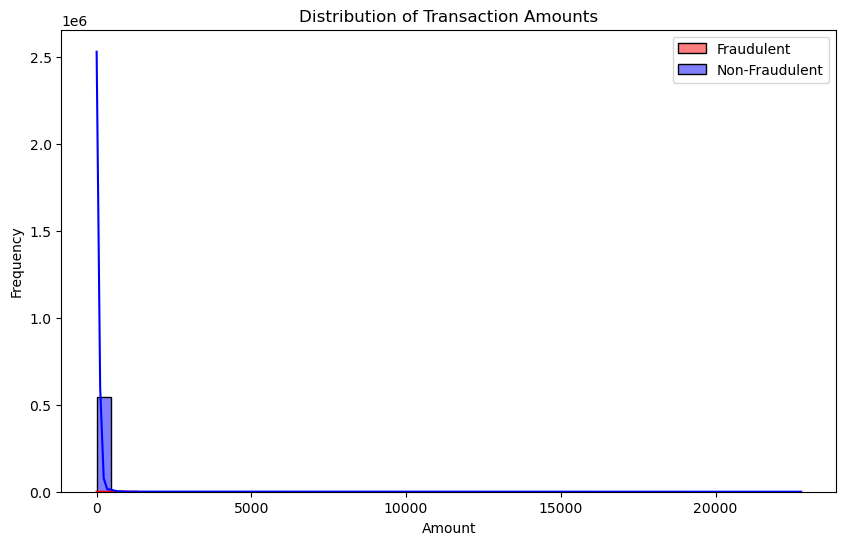

In [31]:
plt.figure(figsize=(10, 6))

# Distribution plot for fraudulent transactions
sns.histplot(data[data['is_fraud'] == 1]['amt'], kde=True, bins=50, color='red', alpha=0.5, label='Fraudulent')

# Distribution plot for non-fraudulent transactions
sns.histplot(data[data['is_fraud'] == 0]['amt'], kde=True, bins=50, color='blue', alpha=0.5, label='Non-Fraudulent')

plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()


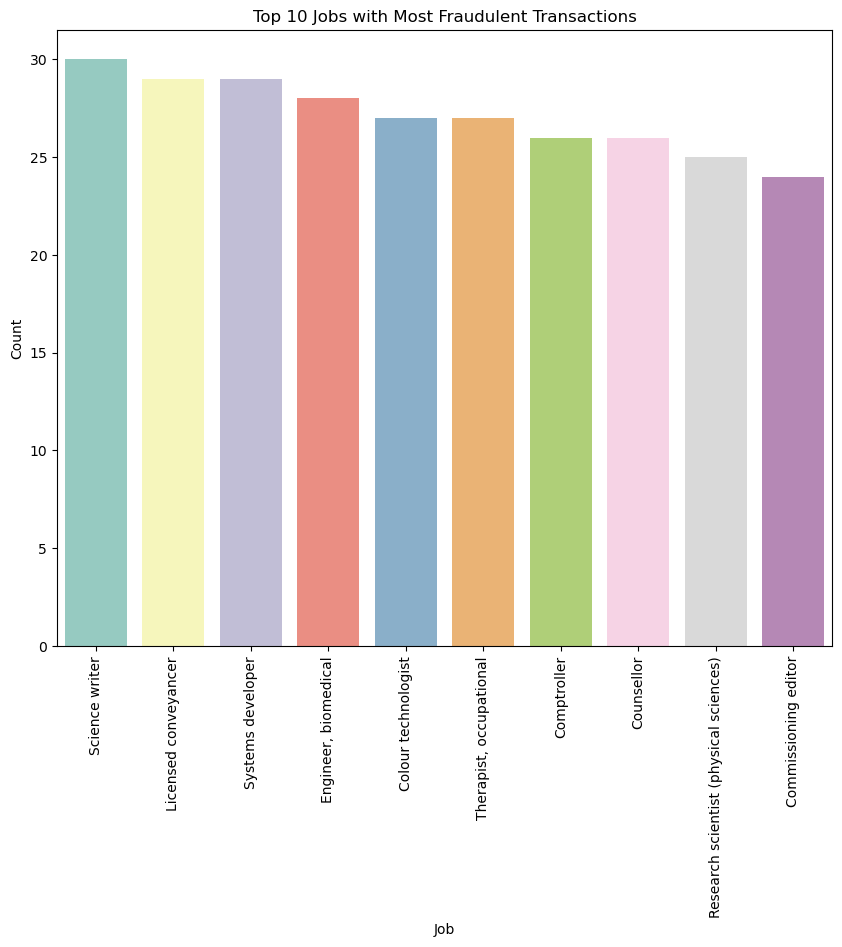

In [32]:
plt.figure(figsize=(10, 8))

# Calculate top fraudulent jobs
top_fraudulent_jobs = fraudulent_transactions['job'].value_counts().head(10).index

# Plot the count plot
sns.countplot(x='job', data=fraudulent_transactions[fraudulent_transactions['job'].isin(top_fraudulent_jobs)], order=top_fraudulent_jobs, palette='Set3')
plt.title('Top 10 Jobs with Most Fraudulent Transactions')
plt.ylabel('Count')
plt.xlabel('Job')
plt.xticks(rotation=90)
plt.show()

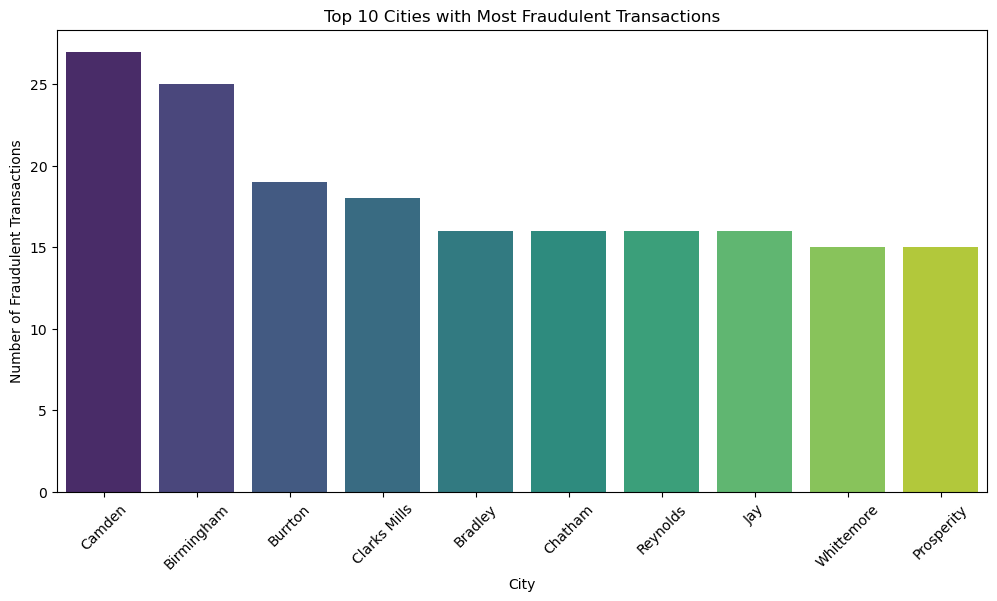

In [33]:
# Assuming 'city' is the column representing the transaction location
top_fraudulent_cities = fraudulent_transactions['city'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_fraudulent_cities.index, y=top_fraudulent_cities.values, palette='viridis')
plt.title('Top 10 Cities with Most Fraudulent Transactions')
plt.xlabel('City')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=45)
plt.show()

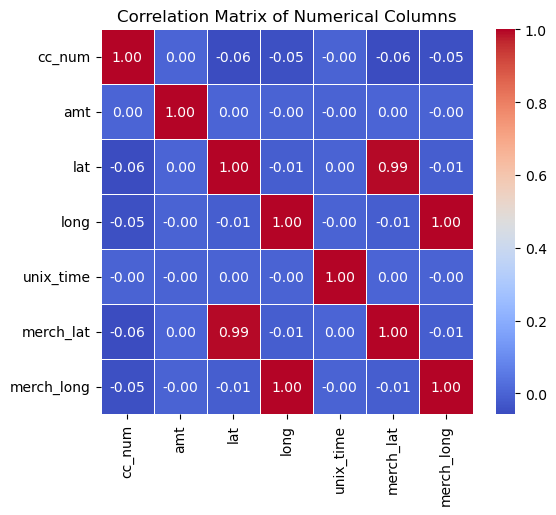

In [34]:
# Select only numerical columns (including 'age' if it was created)
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'age' in data.columns:
    numerical_columns.append('age')

# Compute the correlation matrix for the numerical columns
correlation_matrix = data[numerical_columns].corr()

# Set up the matplotlib figure
plt.figure(figsize=(6, 5))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Add title
plt.title('Correlation Matrix of Numerical Columns')

# Display the plot
plt.show()

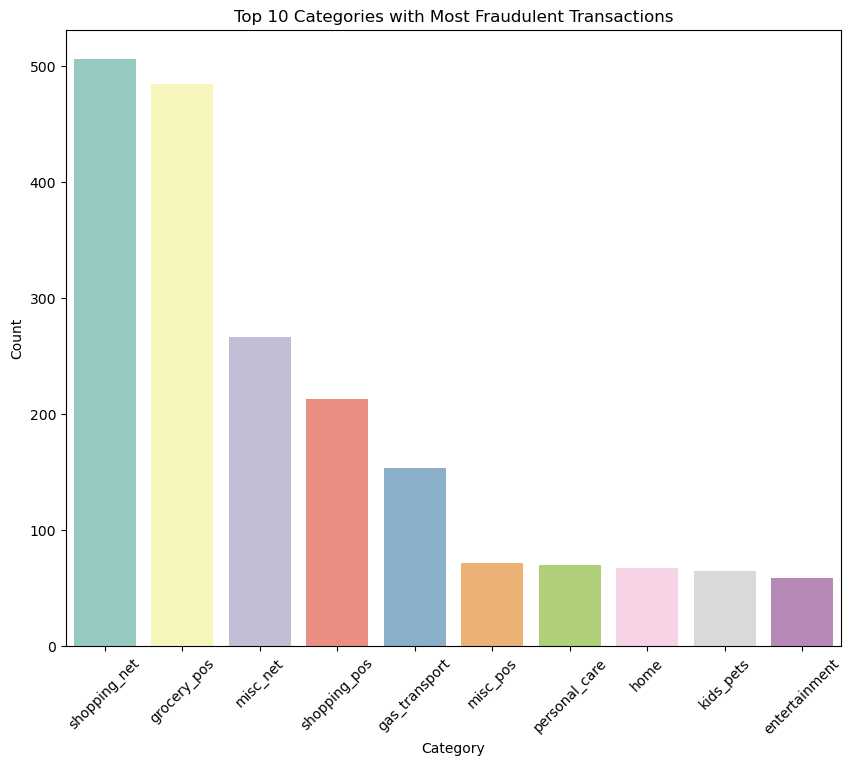

In [35]:
plt.figure(figsize=(10, 8))

# Calculate top fraudulent categories
top_fraudulent_categories = fraudulent_transactions['category'].value_counts().head(10).index

# Plot the count plot
sns.countplot(x='category', data=fraudulent_transactions[fraudulent_transactions['category'].isin(top_fraudulent_categories)], order=top_fraudulent_categories, palette='Set3')
plt.title('Top 10 Categories with Most Fraudulent Transactions')
plt.ylabel('Count')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.show()